YEY AI

In [19]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
import time
import pickle

In [20]:
def covert(img , labels , outfile , n):
    imgf = open(img,"rb")
    labelf = open(labels,"rb")
    csvf = open(outfile,"w")

    imgf.read(16)
    labelf.read(8)
    images = []

    for i in range(n):
        image = [ord(labelf.read(1))]
        for j in range(28*28):
            image.append(ord(imgf.read(1)))
        images.append(image)

    for image in images:
        csvf.write(",".join(str(pix) for pix in image)+ "\n")

    imgf.close()
    labelf.close()
    csvf.close()

In [21]:
mnsit_data = "datasets/train-images.idx3-ubyte"
mnsit_labels = "datasets/train-labels.idx1-ubyte"
mnsit_test_data = "datasets/t10k-images.idx3-ubyte"
mnsit_test_labels = "datasets/t10k-labels.idx1-ubyte"

covert(mnsit_data , mnsit_labels, "datasets/train.csv" , 60000)
covert(mnsit_test_data , mnsit_test_labels, "datasets/test.csv" , 10000)

In [22]:
train_file = open("datasets/train.csv","r")
train_list = train_file.readlines()
train_file.close()
print(len(train_list))

60000


In [23]:
test_file = open("datasets/test.csv","r")
test_list = test_file.readlines()
test_file.close()
print(len(test_list))

10000


In [24]:
train_list[100]

'5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,18,46,136,136,244,255,241,103,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,15,94,163,253,253,253,253,238,218,204,35,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,131,253,253,253,253,237,200,57,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,155,246,253,247,108,65,45,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,207,253,253,230,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,157,253,253,125,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,89,253,250,57,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,89,253,247,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,89,253,247,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,89,253,247,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,

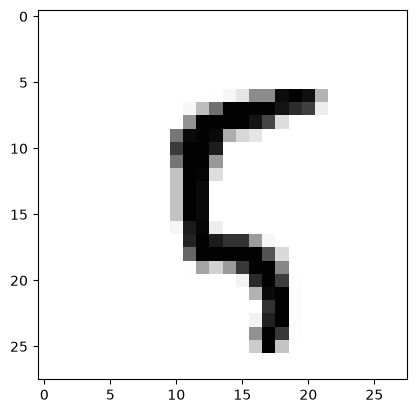

In [27]:
values = train_list[100].split(',')

image_array = np.asarray(
    values[1:],
    dtype=np.uint8
).reshape((28,28))

plt.imshow(image_array, cmap="Greys")
plt.show()

In [28]:
class DNN:
    def __init__(self,sizes=[784,128,64,10],epochs=10,lr=0.001):
        self.sizes = sizes
        self.epochs = epochs
        self.lr = lr

        input_layer = sizes[0]
        hidden_1 = sizes[1]
        hidden_2 = sizes[2]
        output_layer = sizes[3]

        self.params = {
            'W1':np.random.randn(hidden_1,input_layer) * np.sqrt(1./hidden_1),
            'W2':np.random.randn(hidden_2,hidden_1) * np.sqrt(1./hidden_2),
            'W3':np.random.randn(output_layer,hidden_2) * np.sqrt(1./output_layer)

        }

    def sigmoid(self,x,derivative=False):
        if derivative:
            return (np.exp(-x))/((np.exp(-x)+1)**2)
        return 1/(1+np.exp(-x))

    def softmax(self,x,derivative=False):
        exps = np.exp(x-x.max())
        if derivative:
            return exps / np.sum(exps,axis=0) * (1-exps / np.sum(exps,axis=0))

        return exps/np.sum(exps,axis=0)

    def forward_pass(self,x_train):
        params = self.params

        params['A0'] = x_train
        #  hidden 1
        params['Z1'] = np.dot(params['W1'],params['A0'])
        params['A1'] = self.sigmoid(params['Z1'])

        # hiddem 2
        params['Z2'] = np.dot(params['W2'],params['A1'])
        params['A2'] = self.sigmoid(params['Z2'])

        #hidden 2 to ouput
        params['Z3'] = np.dot(params['W3'],params['A2'])
        params['A3'] = self.softmax(params['Z3'])

        return params['A3']

    def backward_pass(self,y_train,output):
        params = self.params

        change_w = {}

        #calculate W3
        error = 2 * (output - y_train) / output.shape[0] * self.softmax(params['Z3'],derivative=True)
        change_w['W3'] = np.outer(error,params['A2'])

        #W2
        error = np.dot(params['W3'].T,error)* self.sigmoid(params['Z2'],derivative=True)
        change_w['W2'] = np.outer(error,params['A1'])

        #W1
        error = np.dot(params['W2'].T,error)* self.sigmoid(params['Z1'],derivative=True)
        change_w['W1'] = np.outer(error,params['A0'])

        return change_w

    def update_weight(self,change_w):
        for key,val in change_w.items():
            self.params[key] -= self.lr * val


    def computer_accuracy(self,test_data):
        predictions = []
        for x in test_list:
            values = x.split(",")
            inputs = (np.asarray(values[1:],dtype=np.float32)/255.0 * 0.99) + 0.01
            targets = np.zeros(10) + 0.01
            targets[int(values[0])] = 0.99
            output = self.forward_pass(inputs)
            pred = np.argmax(output)
            predictions.append(pred==np.argmax(targets))

        return sum(predictions) / len(predictions)

    def predict(self, inputs):
        output = self.forward_pass(inputs)
        return np.argmax(output)


    def train(self , train_list,test_list):
        for i in range(self.epochs):
            start_time = time.time()
            for x in train_list:
                values = x.split(",")
                inputs = (np.asarray(values[1:],dtype=np.float32)/255.0 * 0.99) + 0.01
                targets = np.zeros(10) + 0.01
                targets[int(values[0])] = 0.99
                output = self.forward_pass(inputs)
                change_w = self.backward_pass(targets , output)
                self.update_weight(change_w)

            accuracy = self.computer_accuracy(test_list)
            print('Epoch: {0}, Time Spent: {1:.2f}s, Accuracy: {2:.2f}%'.format(
              i+1, time.time() - start_time, accuracy * 100
          ))




In [44]:
dnn = DNN(sizes=[784,128,64,10],epochs=200,lr=0.001)
dnn.train(train_list,test_list)

with open("model.pkl","wb") as f:
    pickle.dump(dnn.params,f)

Epoch: 1, Time Spent: 19.62s, Accuracy: 24.28%
Epoch: 2, Time Spent: 18.05s, Accuracy: 25.26%
Epoch: 3, Time Spent: 18.26s, Accuracy: 31.18%
Epoch: 4, Time Spent: 17.36s, Accuracy: 35.58%
Epoch: 5, Time Spent: 18.57s, Accuracy: 38.37%
Epoch: 6, Time Spent: 17.44s, Accuracy: 40.73%
Epoch: 7, Time Spent: 17.12s, Accuracy: 43.26%
Epoch: 8, Time Spent: 18.49s, Accuracy: 46.26%
Epoch: 9, Time Spent: 17.99s, Accuracy: 50.35%
Epoch: 10, Time Spent: 18.33s, Accuracy: 53.87%
Epoch: 11, Time Spent: 18.05s, Accuracy: 56.98%
Epoch: 12, Time Spent: 17.72s, Accuracy: 59.00%
Epoch: 13, Time Spent: 17.98s, Accuracy: 60.49%
Epoch: 14, Time Spent: 17.21s, Accuracy: 61.31%
Epoch: 15, Time Spent: 18.27s, Accuracy: 62.02%
Epoch: 16, Time Spent: 17.09s, Accuracy: 62.67%
Epoch: 17, Time Spent: 17.75s, Accuracy: 63.10%
Epoch: 18, Time Spent: 18.18s, Accuracy: 63.40%
Epoch: 19, Time Spent: 17.15s, Accuracy: 63.64%
Epoch: 20, Time Spent: 17.45s, Accuracy: 63.86%
Epoch: 21, Time Spent: 16.95s, Accuracy: 64.04%
E

#ADDING CANVAS TO TEST THE MODEL

In [12]:
from ipycanvas import Canvas
from IPython.display import display

canvas = Canvas(width=280,height=280,sync_image_data = True)

canvas.fill_style = "black"
canvas.fill_rect(0,0,280,280)

canvas.stroke_style = "white"
canvas.line_width = 20

drawing = False

def mouse_down(x,y):
    global drawing
    drawing = True
    canvas.begin_path()
    canvas.move_to(x,y)

def mouse_move(x,y):
    global drawing
    if drawing:
        canvas.line_to(x,y)
        canvas.stroke()

def mouse_up(x,y):
    global drawing
    drawing = False

canvas.on_mouse_down(mouse_down)
canvas.on_mouse_move(mouse_move)
canvas.on_mouse_up(mouse_up)
display(canvas)

Canvas(height=280, sync_image_data=True, width=280)

In [3]:
import ipywidgets as widgets
widgets.IntSlider()

IntSlider(value=0)

In [55]:
img = canvas.get_image_data()
print(img.shape)

(280, 280, 4)


In [81]:
def clear_canvas():
    canvas.fill_style = "black"
    canvas.fill_rect(0,0,280,280)

clear_canvas()

Convertion

In [29]:
from PIL import Image

def get_inputs():
    img = canvas.get_image_data()
    img = Image.fromarray(img)
    img = img.convert("L")  
    img = img.resize((28,28))
    print(img.size)

    pixels = np.array(img)
    print(pixels.shape)

    pixels = 255 - pixels

    inputs = (pixels.flatten()/255.0 * 0.99) + 0.01

    return inputs

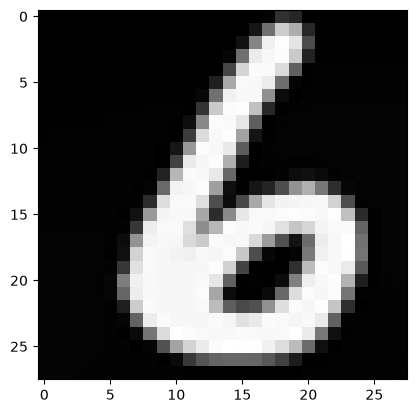

In [35]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img = Image.open("image.png")

img = img.convert("L")      # grayscale
img = img.resize((28,28))

img = np.array(img)

plt.imshow(img, cmap="gray")
plt.show()

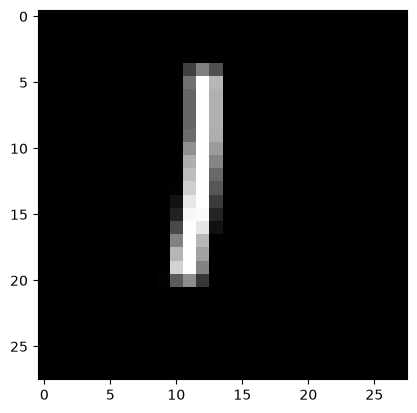

In [101]:
img = canvas.get_image_data()

img = Image.fromarray(img)
img = img.convert("L")
img = img.resize((28,28))

import matplotlib.pyplot as plt

plt.imshow(img, cmap="gray")
plt.show()

In [36]:
inputs = (img.flatten().astype(np.float32) / 255.0 * 0.99) + 0.01

In [37]:
dnn = DNN(sizes=[784,128,64,10])

with open("model.pkl", "rb") as f:
    dnn.params = pickle.load(f)
prediction = dnn.predict(inputs)

print("Prediction:", prediction)

Prediction: 6
